In [1]:
# 1. 라이브러리 불러오기 및 데이터셋 확인

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import pdist

# 시각화 설정
plt.rc('font', family='Malgun Gothic') # 맥 사용자는 'AppleGothic'
plt.rc('axes', unicode_minus=False)

# 손글씨 데이터 로드
digits = load_digits()
X = digits.data
y = digits.target

print("--- [데이터 구조 확인] ---")
print(f"샘플 개수: {X.shape[0]}개")
print(f"변수(차원) 개수: {X.shape[1]}개 (8x8 픽셀 이미지)")
print(f"예측할 정답(클래스): {np.unique(y)} (숫자 0~9)")

--- [데이터 구조 확인] ---
샘플 개수: 1797개
변수(차원) 개수: 64개 (8x8 픽셀 이미지)
예측할 정답(클래스): [0 1 2 3 4 5 6 7 8 9] (숫자 0~9)


In [2]:
# 2. 차원의 저주 눈으로 확인하기 (희소성과 거리의 멀어짐)
# 64차원 공간에서 1,797개의 데이터가 얼마나 멀리 떨어져 방치되어 있는지(희소성) 샘플 간의 유클리드 거리를 계산.

# 전체 샘플 간의 거리 계산
distances = pdist(X, metric='euclidean')

print("\n--- [64차원 공간에서의 데이터 거리 측정] ---")
print(f"샘플 간 평균 거리: {np.mean(distances):.2f}")
print(f"샘플 간 최소 거리: {np.min(distances):.2f}")
print(f"샘플 간 최대 거리: {np.max(distances):.2f}")

# 해석: 0~16 사이의 픽셀값을 가지는 데이터들이지만, 64차원이라는 고차원 우주에 흩어지다 보니 샘플 간의 평균 거리가 40을 넘을 정도로 극단적으로 멀어져 있습니다. 데이터 포인트들이 서로 너무 멀리 떨어져서 텅 빈 공간(Sparsity)을 형성하고 있는 상태.


--- [64차원 공간에서의 데이터 거리 측정] ---
샘플 간 평균 거리: 48.35
샘플 간 최소 거리: 5.29
샘플 간 최대 거리: 77.04



--- [PCA 차원 축소 결과] ---
원본 데이터 모양 : (1797, 64)
축소 후 데이터 모양: (1797, 2)


C:\DEV\dp_312\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10145 (\N{BLACK RIGHTWARDS ARROW}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


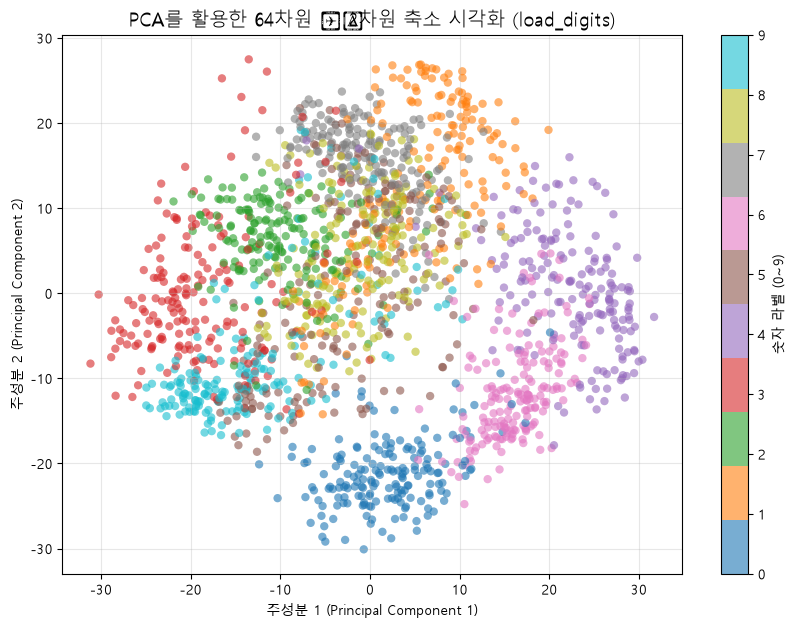

In [3]:
# 3. PCA를 통한 차원 축소 및 2D 시각화
# 차원의 저주 때문에 64차원 상태에서는 사람이 데이터의 분포를. 정보 손실을 최소화하면서 64차원을 단 2차원(PC1, PC2)으로 압축하여 그래프로 그려봅니다.

# PCA 객체 생성 (2개의 주성분으로 압축)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

print("\n--- [PCA 차원 축소 결과] ---")
print(f"원본 데이터 모양 : {X.shape}")      # (1797, 64)
print(f"축소 후 데이터 모양: {X_pca.shape}")  # (1797, 2)

# 2차원 평면에 0부터 9까지의 손글씨 분포 시각화
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.6, edgecolors='none')
plt.colorbar(scatter, label='숫자 라벨 (0~9)')
plt.title('PCA를 활용한 64차원 ➡️ 2차원 축소 시각화 (load_digits)', fontsize=14)
plt.xlabel('주성분 1 (Principal Component 1)')
plt.ylabel('주성분 2 (Principal Component 2)')
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
# 4. 모델 성능 및 속도 개선 비교 (64차원 vs 2차원 PCA)
# 차원의 저주에 걸린 원본 데이터(64차원)와 핵심 요약본 데이터(2차원)로 각각 로지스틱 회귀 모델을 학습시켜 성능과 연산 효율을 비교.

# 훈련/테스트 데이터 분할 (7:3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.3, random_state=42, stratify=y)

import time

# [모델 1] 원본 64차원 데이터 학습
model_orig = LogisticRegression(max_iter=5000, random_state=42)
start_time = time.time()
model_orig.fit(X_train, y_train)
orig_time = time.time() - start_time
orig_acc = accuracy_score(y_test, model_orig.predict(X_test))

# [모델 2] PCA 2차원 데이터 학습
model_pca = LogisticRegression(max_iter=5000, random_state=42)
start_time = time.time()
model_pca.fit(X_train_pca, y_train_pca)
pca_time = time.time() - start_time
pca_acc = accuracy_score(y_test_pca, model_pca.predict(X_test_pca))

# 결과 요약 비교
print("\n--- [최종 분석 및 모델 성능 비교] ---")
print(f"비교 항목\t\t| 원본 데이터 (64차원)\t| PCA 축소 데이터 (2차원)")
print("-" * 75)
print(f"학습 소요 시간\t| {orig_time:.4f} 초\t\t| {pca_time:.4f} 초 (약 {orig_time/pca_time:.1f}배 빠름)")
print(f"테스트 정확도(Acc)\t| {orig_acc*100:.2f}%\t\t| {pca_acc*100:.2f}%")


--- [최종 분석 및 모델 성능 비교] ---
비교 항목		| 원본 데이터 (64차원)	| PCA 축소 데이터 (2차원)
---------------------------------------------------------------------------
학습 소요 시간	| 0.8840 초		| 0.2774 초 (약 3.2배 빠름)
테스트 정확도(Acc)	| 95.74%		| 62.41%
